<a href="https://colab.research.google.com/github/Devadeth-cmyk/ICT-Assignment-and-Assessment/blob/main/CV_CIFAR_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
import pickle     # for loading dataset
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# Read Data

In [7]:
dataset_path = "/content/drive/MyDrive/AI ML/Datasets/CIFAR-100"

# Load dataset
def load_file(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train = load_file(dataset_path + "/train")
test = load_file(dataset_path + "/test")

In [8]:
# Splitting to train and test data
X_train = train[b'data']
y_train = np.array(train[b'fine_labels'])

X_test = test[b'data']
y_test = np.array(test[b'fine_labels'])

#Data Preprocessing

In [9]:
print("Number of classes of dataset:", len(np.unique(y_train)))

Number of classes of dataset: 100


In [10]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 3072)
Training Labels: (50000,)
Testing Images: (10000, 3072)
Testing Labels: (10000,)


In [11]:
print(X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [14]:
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

IndexError: invalid index to scalar variable.

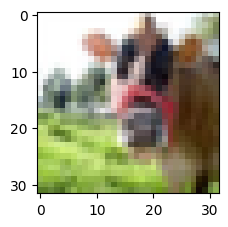

In [15]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i][0])
    plt.axis("off")

plt.show()

In [ ]:
# First, select 10000 images from the original training set
X_subset, _, y_subset, _ = train_test_split(
    X_train,
    y_train,
    train_size = 10000,
    stratify = y_train,
    random_state = 42
)

# Now split the 10000 images into 80% train and 20% test
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_subset,
    y_subset,
    test_size = 0.2,
    stratify = y_subset,
    random_state = 42
)

print(X_train_small.shape)
print(y_train_small.shape)
print(X_test_small.shape)
print(y_test_small.shape)

In [ ]:
# Normalization

X_train_small = X_train_small.astype("float32") / 255.0
X_test_small = X_test_small.astype("float32") / 255.0

In [ ]:
# Onehot encode the labels

y_train_small = to_categorical(y_train_small, 100)
y_test_small = to_categorical(y_test_small, 100)

In [ ]:
# Data Augmentation

train_datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.2
)

train_datagen.fit(X_train_small)

#Model Building

In [ ]:
model = tf.Sequential([

    # Input Layer
    tf.layers.Input(shape=(32, 32, 3)),

    # Block 1
    tf.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer = tf.regularizers.l2(0.0001)
    ),
    tf.layers.BatchNormalization(),
    tf.layers.MaxPooling2D((2, 2)),
    tf.layers.Dropout(0.2),

    # Block 2
    tf.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.regularizers.l2(0.0001)
    ),
    tf.layers.BatchNormalization(),
    tf.layers.MaxPooling2D((2, 2)),
    tf.layers.Dropout(0.3),

    # Block 3
    tf.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.regularizers.l2(0.0001)
    ),
    tf.layers.BatchNormalization(),
    tf.layers.MaxPooling2D((2, 2)),
    tf.layers.Dropout(0.4),

    # Classifier
    tf.layers.GlobalAveragePooling2D(),

    tf.layers.Dense(
        512,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.regularizers.l2(0.0001)
    ),

    tf.layers.Dropout(0.4),

    tf.layers.Dense(
        100,
        activation='softmax'
    )
])

In [ ]:
model.summary()

## Compile Model

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

##Training

In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

In [ ]:
# # Model Training

# history = model.fit(
#     train_datagen.flow(X_train_small, y_train_small, batch_size=32),
#     epochs = 50,
#     validation_data = (X_test_small, y_test_small),
#     callbacks = [early_stop, checkpoint]
# )

#Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test_small, y_test_small)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

In [ ]:
# plt.figure(figsize=(8,5))

# plt.plot(history.history['accuracy'], label = 'Training Accuracy')
# plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

# plt.title('Custom CNN Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.show()

In [ ]:
# print("Training Accuracy:", history.history['accuracy'][-1])
# print("Validation Accuracy:", history.history['val_accuracy'][-1])

# print("Training Loss:", history.history['loss'][-1])
# print("Validation Loss:", history.history['val_loss'][-1])


#VGG Model Building

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation='relu',
    kernel_initializer='he_normal'
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    100,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [ ]:
optimizer = tf.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = 224

def preprocess(image, label):
    image = tfio.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

train_dataset = (
    tfio.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
    .map(preprocess, num_parallel_calls = tfio.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tfio.data.AUTOTUNE)
)

val_dataset = (
    tfio.data.Dataset.from_tensor_slices((X_test_small, y_test_small))
    .map(preprocess, num_parallel_calls=tfio.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tfio.data.AUTOTUNE)
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

In [ ]:
loss, accuracy = model.evaluate(val_dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)